<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Neural Networks and Deep Learning</b><br><br>Computer Assignment 5</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Instructor: Prof. Ahmad Kalhor
    </div>
</div>

>[Robust Zero-Shot Classification via Parameter-Efficient Adversarial Fine-Tuning of CLIP](#scrollTo=qpRKwvmKADDy)

>>[Section 1: Data Preparation and Preprocessing](#scrollTo=wU1FMgumAVdo)

>>>[Environment Setup](#scrollTo=pEXGRDxKdCrG)

>>>[CIFAR-10 Data Preparation](#scrollTo=nVXGLdkYdqzY)

>>[Section 2: Load Pre-trained Models](#scrollTo=N8xIYIJydVCH)

>>[Section 3: Evaluate CLIP and Generate Adversarial Examples](#scrollTo=F-Nyzqv1e0NT)

>>[Section 4: LoRA Implementation and Adversarial Training for CLIP](#scrollTo=8cn9aSXzfDOU)

>>[Section 5: Implement TeCoA Training](#scrollTo=xax1FgREfWKe)

>>[Section 6: Comprehensive Comparison of Different Training Methods](#scrollTo=3-lih2kLfqCk)

>>[Section 7 (Bonus): Visual Prompting Tuning with TeCoA and Comprehensive Evaluation and Comparison](#scrollTo=VLAXB9iCfwcE)



# Robust Zero-Shot Classification via Parameter-Efficient Adversarial Fine-Tuning of CLIP

## Section 1: Data Preparation and Preprocessing

### Environment Setup

In [ ]:
!pip install torchattacks

In [2]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset, random_split
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from tqdm.auto import tqdm
from PIL import Image
import torchattacks
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer, CLIPTextModel, CLIPVisionModel
from peft import LoraConfig, get_peft_model, TaskType
import pandas as pd
import random
import warnings
warnings.filterwarnings('ignore')
import copy
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### CIFAR-10 Data Preparation

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [00:06<00:00, 26.1MB/s]


Using 10000 images for training.
Using 2500 images for validation.
Using 10000 images for testing.
Displaying 5 random samples from training dataset:


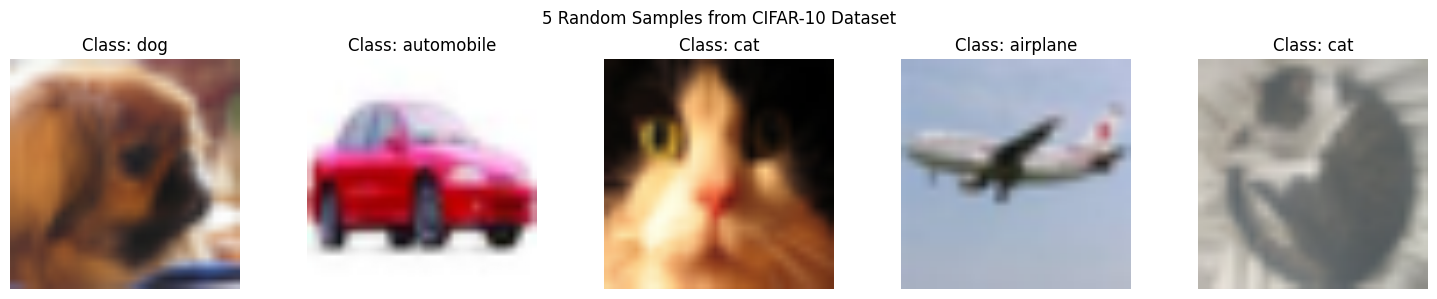


Training Dataset Distribution:
Class Distribution:
        Class  Count  Percentage
0    airplane   1024       10.24
1  automobile    996        9.96
2        bird    983        9.83
3         cat    990        9.90
4        deer    995        9.95
5         dog    981        9.81
6        frog   1029       10.29
7       horse   1022       10.22
8        ship    980        9.80
9       truck   1000       10.00


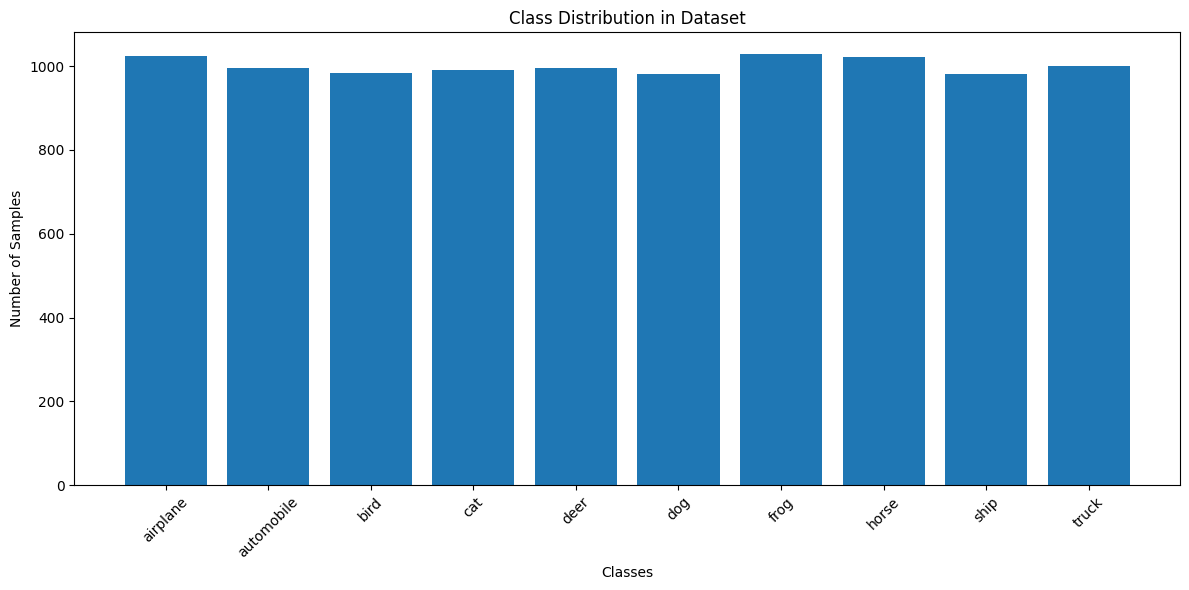


Validation Dataset Distribution:
Class Distribution:
        Class  Count  Percentage
0    airplane    259       10.36
1  automobile    260       10.40
2        bird    248        9.92
3         cat    254       10.16
4        deer    267       10.68
5         dog    236        9.44
6        frog    250       10.00
7       horse    242        9.68
8        ship    253       10.12
9       truck    231        9.24


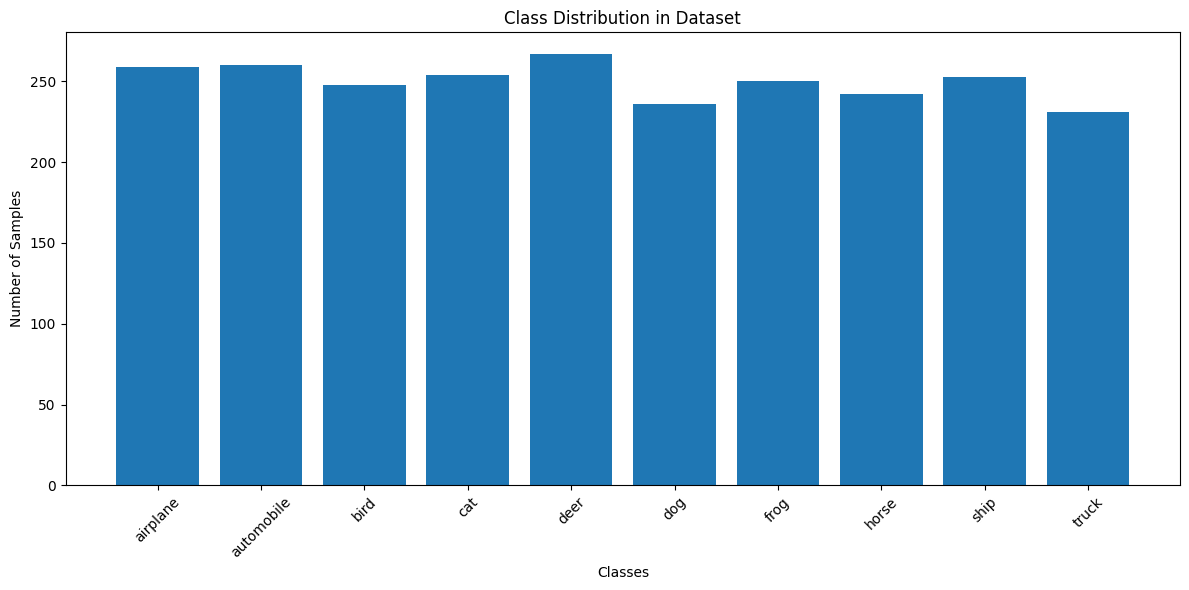


Test Dataset Distribution:
Class Distribution:
        Class  Count  Percentage
0    airplane   1000        10.0
1  automobile   1000        10.0
2        bird   1000        10.0
3         cat   1000        10.0
4        deer   1000        10.0
5         dog   1000        10.0
6        frog   1000        10.0
7       horse   1000        10.0
8        ship   1000        10.0
9       truck   1000        10.0


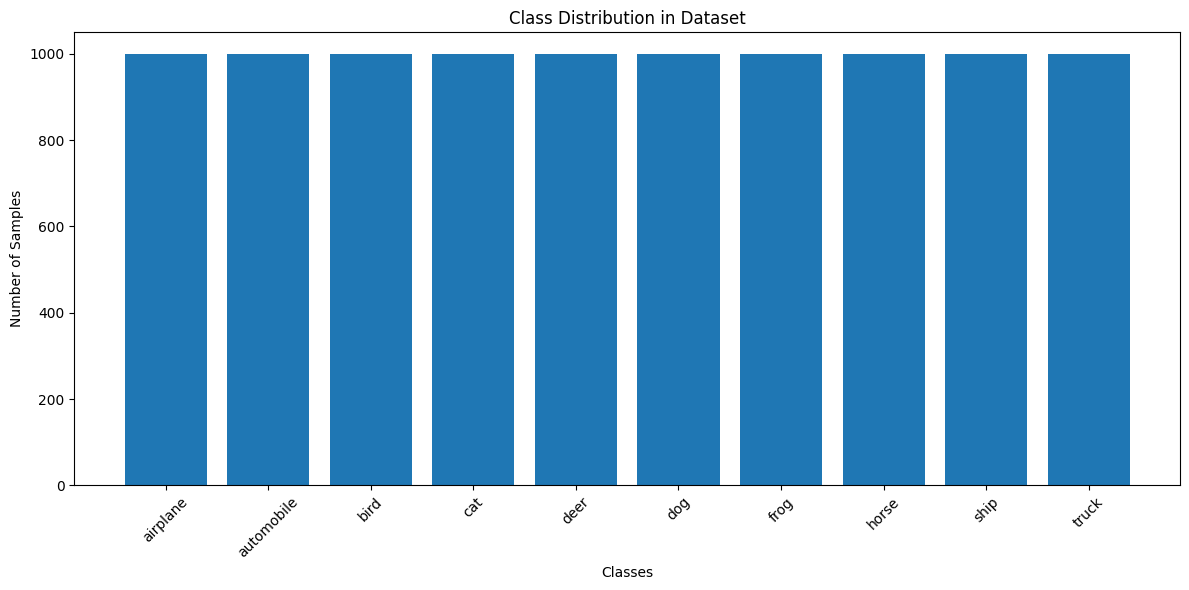


Section 1 Complete: Data has been properly preprocessed and split into train/validation/test sets


In [3]:
# Define CIFAR-10 classes
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Download and prepare CIFAR-10 dataset with proper preprocessing
def prepare_cifar10_datasets():
    """
    Prepare CIFAR-10 dataset with proper preprocessing for CLIP
    Returns train, validation, and test datasets with their respective loaders
    """
    # CLIP model uses specific preprocessing
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                             std=[0.26862954, 0.26130258, 0.27577711])
    ])

    # Load full training and test datasets
    # Load CIFAR-10 dataset
    print("Loading CIFAR-10 dataset...")
    full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    # As per homework note, I could use a subset of training data.
    # Let's use 20% for training and 5% for validation for faster experiments.
    train_size = int(0.20 * len(full_train_dataset))
    val_size = int(0.05 * len(full_train_dataset))
    remaining_size = len(full_train_dataset) - train_size - val_size
    train_dataset, val_dataset, _ = random_split(full_train_dataset, [train_size, val_size, remaining_size])

    # Create data loaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Using {len(train_dataset)} images for training.")
    print(f"Using {len(val_dataset)} images for validation.")
    print(f"Using {len(test_dataset)} images for testing.")

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

# Function to display 5 random samples from dataset
def display_random_samples(dataset, num_samples=5):
    """
    Display 5 random samples from the dataset
    """
    # Get random indices
    random_indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(15, 3))
    for i, idx in enumerate(random_indices):
        # Get image and label
        if hasattr(dataset, 'dataset'):  # For Subset objects
            image, label = dataset.dataset[dataset.indices[idx]]
        else:
            image, label = dataset[idx]

        plt.subplot(1, num_samples, i+1)

        # Denormalize image for display
        img = image.permute(1, 2, 0)
        img = img * torch.tensor([0.26862954, 0.26130258, 0.27577711]) + torch.tensor([0.48145466, 0.4578275, 0.40821073])
        img = torch.clamp(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Class: {CIFAR10_CLASSES[label]}")
        plt.axis('off')

    plt.suptitle("5 Random Samples from CIFAR-10 Dataset")
    plt.tight_layout()
    plt.show()

# Prepare datasets
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = prepare_cifar10_datasets()

# Display 5 random samples
print("Displaying 5 random samples from training dataset:")
display_random_samples(train_dataset)

# Check class distribution
def check_class_distribution(dataset):
    """
    Check the distribution of classes in the dataset
    """
    class_counts = [0] * 10

    if hasattr(dataset, 'dataset'):  # For Subset objects
        for idx in dataset.indices:
            _, label = dataset.dataset[idx]
            class_counts[label] += 1
    else:
        for _, label in dataset:
            class_counts[label] += 1

    # Create distribution table
    distribution_df = pd.DataFrame({
        'Class': CIFAR10_CLASSES,
        'Count': class_counts,
        'Percentage': [count/sum(class_counts)*100 for count in class_counts]
    })

    print("Class Distribution:")
    print(distribution_df)

    # Visualize distribution
    plt.figure(figsize=(12, 6))
    plt.bar(CIFAR10_CLASSES, class_counts)
    plt.title('Class Distribution in Dataset')
    plt.xlabel('Classes')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return distribution_df

print("\nTraining Dataset Distribution:")
train_dist = check_class_distribution(train_dataset)

print("\nValidation Dataset Distribution:")
val_dist = check_class_distribution(val_dataset)

print("\nTest Dataset Distribution:")
test_dist = check_class_distribution(test_dataset)

print("\nSection 1 Complete: Data has been properly preprocessed and split into train/validation/test sets")

## Section 2: Load Pre-trained Models

In [4]:
def load_clip_model():
    """
    Load pre-trained CLIP model and processor
    """
    model_name = "openai/clip-vit-base-patch32"
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)
    tokenizer = CLIPTokenizer.from_pretrained(model_name)

    print(f"CLIP model loaded: {model_name}")
    return model.to(device), processor, tokenizer

def load_resnet20():
    """
    Load pre-trained ResNet20 model for CIFAR-10
    """
    model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
    model.eval()
    print("ResNet20 model loaded and set to evaluation mode")
    return model.to(device)

def prepare_text_embeddings(clip_model, tokenizer):
    """
    Prepare text embeddings for all CIFAR-10 classes
    """
    # Create text prompts for each class
    text_prompts = [f"a photo of a {class_name}" for class_name in CIFAR10_CLASSES]

    # Tokenize text and get embeddings
    text_inputs = tokenizer(text_prompts, padding=True, return_tensors="pt").to(device)

    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)
        text_features = F.normalize(text_features, dim=1)

    print("Text embeddings prepared for all CIFAR-10 classes")
    return text_features

# Load all models
print("Loading pre-trained models...")
clip_model, processor, tokenizer = load_clip_model()
resnet20_model = load_resnet20()
text_features = prepare_text_embeddings(clip_model, tokenizer)

print("\nSection 2 Complete: All pre-trained models loaded successfully")

Loading pre-trained models...


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded: openai/clip-vit-base-patch32


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt
100%|██████████| 1.09M/1.09M [00:00<00:00, 25.9MB/s]


ResNet20 model loaded and set to evaluation mode
Text embeddings prepared for all CIFAR-10 classes

Section 2 Complete: All pre-trained models loaded successfully


## Section 3: Evaluate CLIP and Generate Adversarial Examples

Section 3: CLIP Evaluation and Adversarial Attack Analysis


Evaluating CLIP (Clean):   0%|          | 0/313 [00:00<?, ?it/s]

CLIP Clean Accuracy: 0.8783 (8783/10000)


Evaluating CLIP (Adversarial):   0%|          | 0/313 [00:00<?, ?it/s]

CLIP Adversarial Accuracy: 0.0023 (23/10000)


Testing Transferability:   0%|          | 0/313 [00:00<?, ?it/s]

Transfer Attack Results:
CLIP Clean Accuracy: 0.8809
CLIP Accuracy on ResNet Adversarial Examples: 0.4951
Attack Success Rate: 0.5049

Summary of Results:
CLIP Clean Accuracy: 0.8783
CLIP Adversarial Accuracy (Direct PGD): 0.0023
CLIP Accuracy on Transferred Attacks: 0.4951
Vulnerability Demonstrated: 0.8760 accuracy drop
Visualizing Adversarial Examples
Generating adversarial example visualizations...


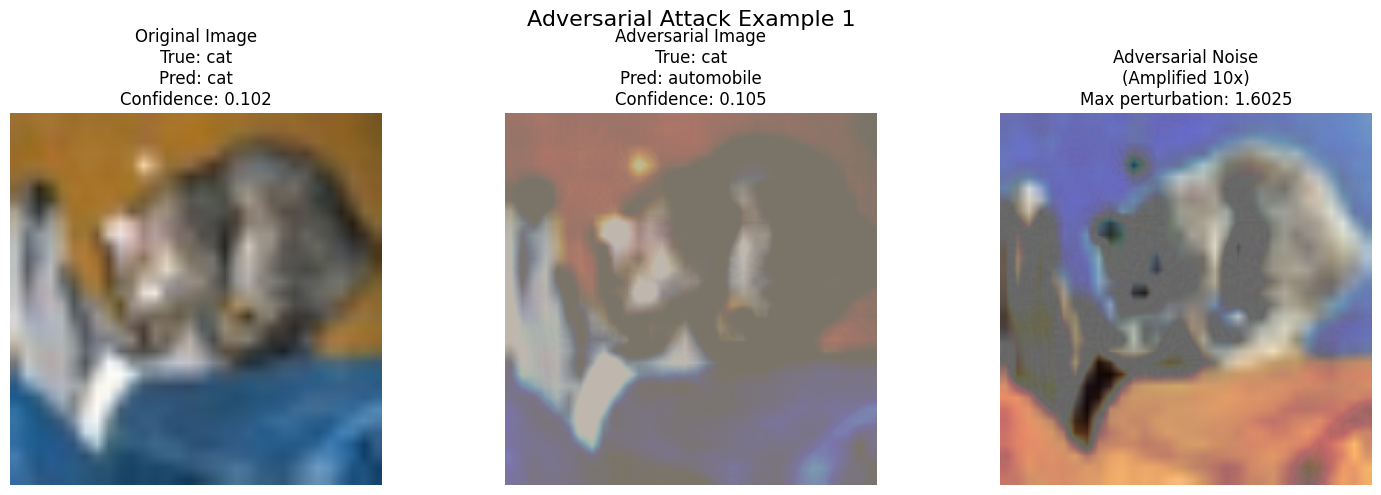


Example 1 Analysis:
True Label: cat
Original Prediction: cat (Confidence: 0.102)
Adversarial Prediction: automobile (Confidence: 0.105)
Attack Success: Yes
L∞ Perturbation: 1.602483
L2 Perturbation: 196.214645
--------------------------------------------------


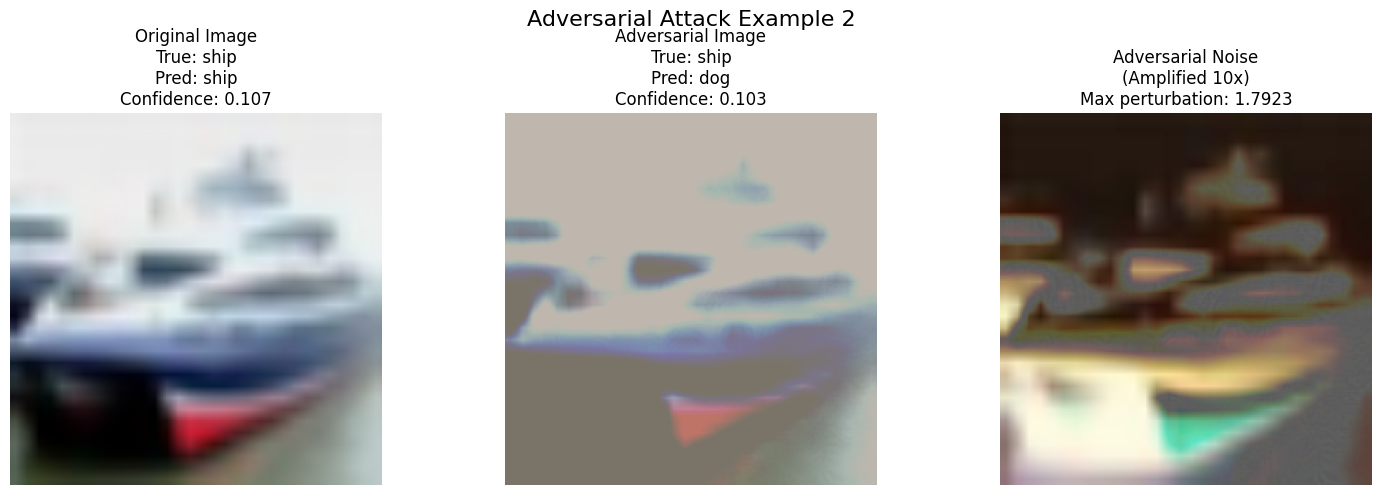


Example 2 Analysis:
True Label: ship
Original Prediction: ship (Confidence: 0.107)
Adversarial Prediction: dog (Confidence: 0.103)
Attack Success: Yes
L∞ Perturbation: 1.792263
L2 Perturbation: 285.493378
--------------------------------------------------


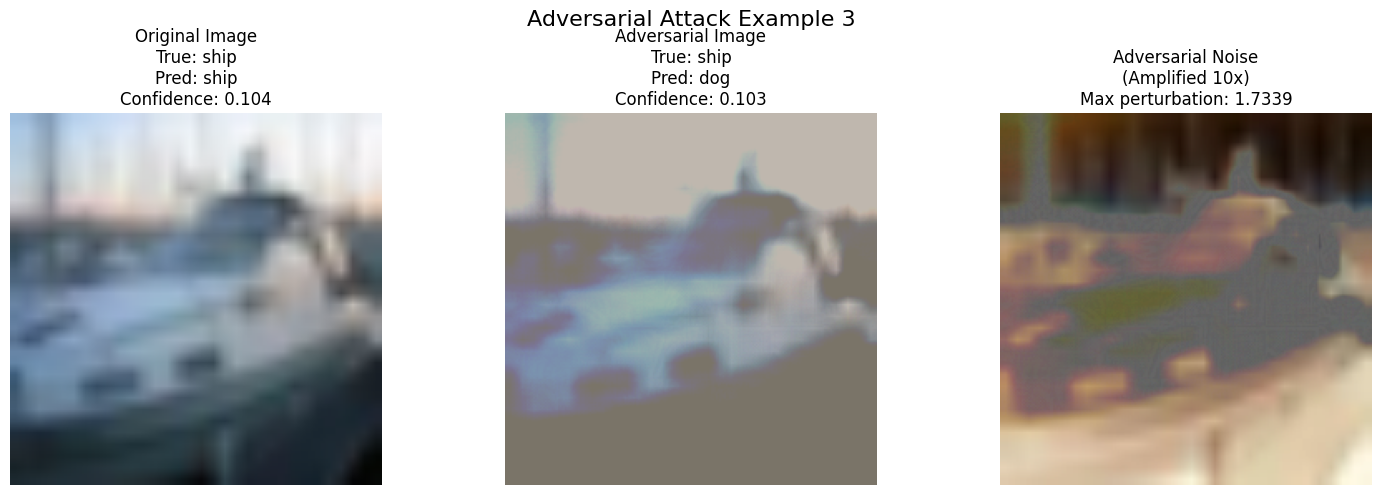


Example 3 Analysis:
True Label: ship
Original Prediction: ship (Confidence: 0.104)
Adversarial Prediction: dog (Confidence: 0.103)
Attack Success: Yes
L∞ Perturbation: 1.733869
L2 Perturbation: 236.590027
--------------------------------------------------

Analyzing attack statistics...

Adversarial Attack Statistics (on 224 samples):
Attack Success Rate: 0.987 (221/224)
Average L∞ Perturbation: 1.567742
Average L2 Perturbation: 1.567742
Average Confidence Drop: 0.001

Section 3 Complete: CLIP vulnerability demonstrated with visual examples
Key Findings:
- Clean Accuracy: 0.8783
- Adversarial Accuracy: 0.0023
- Attack Success Rate: 0.987
- Average Perturbation: 1.567742

Section 3 Complete: CLIP vulnerability to adversarial attacks demonstrated


In [ ]:
# Section 3: CLIP Evaluation and PGD Attack Implementation

def evaluate_clip_zero_shot(clip_model, processor, test_loader, text_features, device):
    """
    Evaluate CLIP model on clean images using zero-shot classification
    """
    clip_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating CLIP (Clean)"):
            images = images.to(device)
            labels = labels.to(device)

            # Get image features from CLIP
            image_features = clip_model.get_image_features(images)
            image_features = F.normalize(image_features, dim=1)

            # Compute similarity with text features
            similarity = torch.matmul(image_features, text_features.T)
            predictions = similarity.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"CLIP Clean Accuracy: {accuracy:.4f} ({correct}/{total})")
    return accuracy

def pgd_attack(model, images, labels, text_features, eps=8/255, alpha=2/255, steps=7):
    """
    Projected Gradient Descent (PGD) attack implementation for CLIP
    """
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    # Initialize adversarial images
    adv_images = images.clone().detach()

    # Add random noise within epsilon ball
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(steps):
        adv_images.requires_grad_(True)

        # Forward pass
        image_features = model.get_image_features(adv_images)
        image_features = F.normalize(image_features, dim=1)

        # Compute similarity and loss
        similarity = torch.matmul(image_features, text_features.T)
        loss = F.cross_entropy(similarity, labels)

        # Backward pass
        grad = torch.autograd.grad(loss, adv_images,
                                 retain_graph=False, create_graph=False)[0]

        # Update adversarial images
        adv_images = adv_images.detach() + alpha * grad.sign()
        delta = torch.clamp(adv_images - images, min=-eps, max=eps)
        adv_images = torch.clamp(images + delta, min=0, max=1).detach()

    return adv_images

def evaluate_clip_adversarial(clip_model, processor, test_loader, text_features, device):
    """
    Evaluate CLIP model on adversarial images
    """
    clip_model.eval()
    correct = 0
    total = 0

    for images, labels in tqdm(test_loader, desc="Evaluating CLIP (Adversarial)"):
        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial examples
        adv_images = pgd_attack(clip_model, images, labels, text_features)

        with torch.no_grad():
            # Get image features from adversarial images
            image_features = clip_model.get_image_features(adv_images)
            image_features = F.normalize(image_features, dim=1)

            # Compute similarity with text features
            similarity = torch.matmul(image_features, text_features.T)
            predictions = similarity.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"CLIP Adversarial Accuracy: {accuracy:.4f} ({correct}/{total})")
    return accuracy

def demonstrate_transferability(clip_model, resnet_model, test_loader, text_features, device):
    """
    Demonstrate transferability of adversarial attacks from ResNet to CLIP
    """
    clip_model.eval()
    resnet_model.eval()

    # Transform for ResNet (32x32 input)
    resnet_transform = transforms.Compose([
        transforms.Resize(32),
        transforms.CenterCrop(32),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    correct_clean = 0
    correct_adv = 0
    total = 0

    for images, labels in tqdm(test_loader, desc="Testing Transferability"):
        if total >= 1000:  # Limit for demonstration
            break

        images = images.to(device)
        labels = labels.to(device)

        # Resize images for ResNet
        resnet_images = F.interpolate(images, size=(32, 32), mode='bilinear')

        # Generate adversarial examples using ResNet
        resnet_images.requires_grad_(True)
        outputs = resnet_model(resnet_images)
        loss = F.cross_entropy(outputs, labels)
        grad = torch.autograd.grad(loss, resnet_images)[0]

        # Create adversarial perturbation
        eps = 8/255
        perturbation = eps * grad.sign()
        adv_resnet_images = torch.clamp(resnet_images + perturbation, 0, 1)

        # Resize back to CLIP input size
        adv_clip_images = F.interpolate(adv_resnet_images, size=(224, 224), mode='bilinear')

        with torch.no_grad():
            # Test on clean images
            clean_features = clip_model.get_image_features(images)
            clean_features = F.normalize(clean_features, dim=1)
            clean_similarity = torch.matmul(clean_features, text_features.T)
            clean_pred = clean_similarity.argmax(dim=1)

            # Test on adversarial images
            adv_features = clip_model.get_image_features(adv_clip_images)
            adv_features = F.normalize(adv_features, dim=1)
            adv_similarity = torch.matmul(adv_features, text_features.T)
            adv_pred = adv_similarity.argmax(dim=1)

            correct_clean += (clean_pred == labels).sum().item()
            correct_adv += (adv_pred == labels).sum().item()
            total += labels.size(0)

    clean_acc = correct_clean / total
    adv_acc = correct_adv / total

    print(f"Transfer Attack Results:")
    print(f"CLIP Clean Accuracy: {clean_acc:.4f}")
    print(f"CLIP Accuracy on ResNet Adversarial Examples: {adv_acc:.4f}")
    print(f"Attack Success Rate: {1 - adv_acc:.4f}")

    return clean_acc, adv_acc

# Run evaluations
print("=" * 60)
print("Section 3: CLIP Evaluation and Adversarial Attack Analysis")
print("=" * 60)

# Evaluate CLIP on clean images
clean_accuracy = evaluate_clip_zero_shot(clip_model, processor, test_loader, text_features, device)

# Evaluate CLIP on adversarial images
adversarial_accuracy = evaluate_clip_adversarial(clip_model, processor, test_loader, text_features, device)

# Demonstrate transferability
clean_acc, transfer_acc = demonstrate_transferability(clip_model, resnet20_model, test_loader, text_features, device)

print(f"\nSummary of Results:")
print(f"CLIP Clean Accuracy: {clean_accuracy:.4f}")
print(f"CLIP Adversarial Accuracy (Direct PGD): {adversarial_accuracy:.4f}")
print(f"CLIP Accuracy on Transferred Attacks: {transfer_acc:.4f}")
print(f"Vulnerability Demonstrated: {clean_accuracy - adversarial_accuracy:.4f} accuracy drop")

def visualize_adversarial_example(clip_model, processor, test_loader, text_features, device, num_examples=1):
    """
    Visualize adversarial examples: original image, adversarial image, and noise
    """
    clip_model.eval()

    # Get a batch of test images
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial examples
        adv_images = pgd_attack(clip_model, images, labels, text_features)

        # Calculate noise (perturbation)
        noise = adv_images - images

        # Select first few examples for visualization
        for i in range(min(num_examples, images.size(0))):
            # Convert tensors to numpy for visualization
            original = images[i].cpu().detach()
            adversarial = adv_images[i].cpu().detach()
            perturbation = noise[i].cpu().detach()
            true_label = labels[i].cpu().item()

            # Denormalize images for display
            mean = torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(3, 1, 1)
            std = torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(3, 1, 1)

            original_denorm = original * std + mean
            adversarial_denorm = adversarial * std + mean

            # Clamp values to [0, 1]
            original_denorm = torch.clamp(original_denorm, 0, 1)
            adversarial_denorm = torch.clamp(adversarial_denorm, 0, 1)

            # Get predictions
            with torch.no_grad():
                # Original image prediction
                orig_features = clip_model.get_image_features(original.unsqueeze(0).to(device))
                orig_features = F.normalize(orig_features, dim=1)
                orig_similarity = torch.matmul(orig_features, text_features.T)
                orig_pred = orig_similarity.argmax(dim=1).cpu().item()
                orig_confidence = F.softmax(orig_similarity, dim=1).max().cpu().item()

                # Adversarial image prediction
                adv_features = clip_model.get_image_features(adversarial.unsqueeze(0).to(device))
                adv_features = F.normalize(adv_features, dim=1)
                adv_similarity = torch.matmul(adv_features, text_features.T)
                adv_pred = adv_similarity.argmax(dim=1).cpu().item()
                adv_confidence = F.softmax(adv_similarity, dim=1).max().cpu().item()

            # Create visualization
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            # Original image
            axes[0].imshow(original_denorm.permute(1, 2, 0))
            axes[0].set_title(f'Original Image\nTrue: {CIFAR10_CLASSES[true_label]}\n'
                            f'Pred: {CIFAR10_CLASSES[orig_pred]}\n'
                            f'Confidence: {orig_confidence:.3f}')
            axes[0].axis('off')

            # Adversarial image
            axes[1].imshow(adversarial_denorm.permute(1, 2, 0))
            axes[1].set_title(f'Adversarial Image\nTrue: {CIFAR10_CLASSES[true_label]}\n'
                            f'Pred: {CIFAR10_CLASSES[adv_pred]}\n'
                            f'Confidence: {adv_confidence:.3f}')
            axes[1].axis('off')

            # Noise/Perturbation (amplified for visibility)
            noise_vis = perturbation * 10  # Amplify for better visualization
            noise_vis = (noise_vis - noise_vis.min()) / (noise_vis.max() - noise_vis.min())
            axes[2].imshow(noise_vis.permute(1, 2, 0))
            axes[2].set_title('Adversarial Noise\n(Amplified 10x)\n'
                            f'Max perturbation: {perturbation.abs().max():.4f}')
            axes[2].axis('off')

            plt.suptitle(f'Adversarial Attack Example {i+1}', fontsize=16)
            plt.tight_layout()
            plt.show()

            # Print detailed information
            print(f"\nExample {i+1} Analysis:")
            print(f"True Label: {CIFAR10_CLASSES[true_label]}")
            print(f"Original Prediction: {CIFAR10_CLASSES[orig_pred]} (Confidence: {orig_confidence:.3f})")
            print(f"Adversarial Prediction: {CIFAR10_CLASSES[adv_pred]} (Confidence: {adv_confidence:.3f})")
            print(f"Attack Success: {'Yes' if orig_pred != adv_pred else 'No'}")
            print(f"L∞ Perturbation: {perturbation.abs().max():.6f}")
            print(f"L2 Perturbation: {torch.norm(perturbation).item():.6f}")
            print("-" * 50)

        break  # Only process first batch

def analyze_attack_statistics(clip_model, processor, test_loader, text_features, device, num_samples=100):
    """
    Analyze statistics of adversarial attacks
    """
    clip_model.eval()

    attack_success = 0
    total_samples = 0
    perturbation_norms = []
    confidence_drops = []

    for images, labels in test_loader:
        if total_samples >= num_samples:
            break

        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial examples
        adv_images = pgd_attack(clip_model, images, labels, text_features)

        with torch.no_grad():
            # Original predictions
            orig_features = clip_model.get_image_features(images)
            orig_features = F.normalize(orig_features, dim=1)
            orig_similarity = torch.matmul(orig_features, text_features.T)
            orig_pred = orig_similarity.argmax(dim=1)
            orig_confidence = F.softmax(orig_similarity, dim=1).max(dim=1)[0]

            # Adversarial predictions
            adv_features = clip_model.get_image_features(adv_images)
            adv_features = F.normalize(adv_features, dim=1)
            adv_similarity = torch.matmul(adv_features, text_features.T)
            adv_pred = adv_similarity.argmax(dim=1)
            adv_confidence = F.softmax(adv_similarity, dim=1).max(dim=1)[0]

            # Calculate statistics
            successful_attacks = (orig_pred != adv_pred).sum().item()
            attack_success += successful_attacks
            total_samples += images.size(0)

            # Perturbation norms
            perturbations = adv_images - images
            l_inf_norms = perturbations.abs().max(dim=1)[0].max(dim=1)[0].max(dim=1)[0]
            l2_norms = torch.norm(perturbations.view(perturbations.size(0), -1), dim=1)

            perturbation_norms.extend(l_inf_norms.cpu().tolist())
            confidence_drops.extend((orig_confidence - adv_confidence).cpu().tolist())

    # Print statistics
    print(f"\nAdversarial Attack Statistics (on {total_samples} samples):")
    print(f"Attack Success Rate: {attack_success/total_samples:.3f} ({attack_success}/{total_samples})")
    print(f"Average L∞ Perturbation: {np.mean(perturbation_norms):.6f}")
    print(f"Average L2 Perturbation: {np.mean([torch.norm(torch.tensor(p)).item() for p in perturbation_norms]):.6f}")
    print(f"Average Confidence Drop: {np.mean(confidence_drops):.3f}")

    return {
        'success_rate': attack_success/total_samples,
        'avg_linf_perturbation': np.mean(perturbation_norms),
        'avg_confidence_drop': np.mean(confidence_drops)
    }

print("=" * 60)
print("Visualizing Adversarial Examples")
print("=" * 60)

# Visualize adversarial examples
print("Generating adversarial example visualizations...")
visualize_adversarial_example(clip_model, processor, test_loader, text_features, device, num_examples=3)

# Analyze attack statistics
print("\nAnalyzing attack statistics...")
attack_stats = analyze_attack_statistics(clip_model, processor, test_loader, text_features, device, num_samples=200)

print(f"\nSection 3 Complete: CLIP vulnerability demonstrated with visual examples")
print(f"Key Findings:")
print(f"- Clean Accuracy: {clean_accuracy:.4f}")
print(f"- Adversarial Accuracy: {adversarial_accuracy:.4f}")
print(f"- Attack Success Rate: {attack_stats['success_rate']:.3f}")
print(f"- Average Perturbation: {attack_stats['avg_linf_perturbation']:.6f}")

print("\nSection 3 Complete: CLIP vulnerability to adversarial attacks demonstrated")

## Section 4: LoRA Implementation and Adversarial Training for CLIP


Section 4: LoRA Implementation and Clean Training
LoRA Configuration:
- Rank (r): 8
- Alpha: 32
- Target modules: {'v_proj', 'q_proj'}
trainable params: 294,912 || all params: 87,750,912 || trainable%: 0.3361
Trainable parameter: base_model.model.encoder.layers.0.self_attn.v_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.0.self_attn.v_proj.lora_B.default.weight
Trainable parameter: base_model.model.encoder.layers.0.self_attn.q_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.0.self_attn.q_proj.lora_B.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.v_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.v_proj.lora_B.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.q_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.q_proj.lora_B.default.weight
Trainable parameter: base_model.model.

LoRA Training Epoch 1/10:   0%|          | 0/313 [00:00<?, ?it/s]


--- End of Epoch 1 ---


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Evaluating LoRA CLIP (clean):   0%|          | 0/313 [00:00<?, ?it/s]

...

Evaluating LoRA CLIP (clean):   0%|          | 0/313 [00:00<?, ?it/s]

LoRA CLIP Clean Accuracy: 0.9481 (9481/10000)
Now performing adversarial evaluation (this may take longer)...


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Evaluating LoRA CLIP (adversarial):   0%|          | 0/313 [00:00<?, ?it/s]

LoRA CLIP Adversarial Accuracy: 0.6116 (6116/10000)

LoRA Results Summary:
Final Test Clean Accuracy: 0.9481
Final Test Adversarial Accuracy: 0.6116


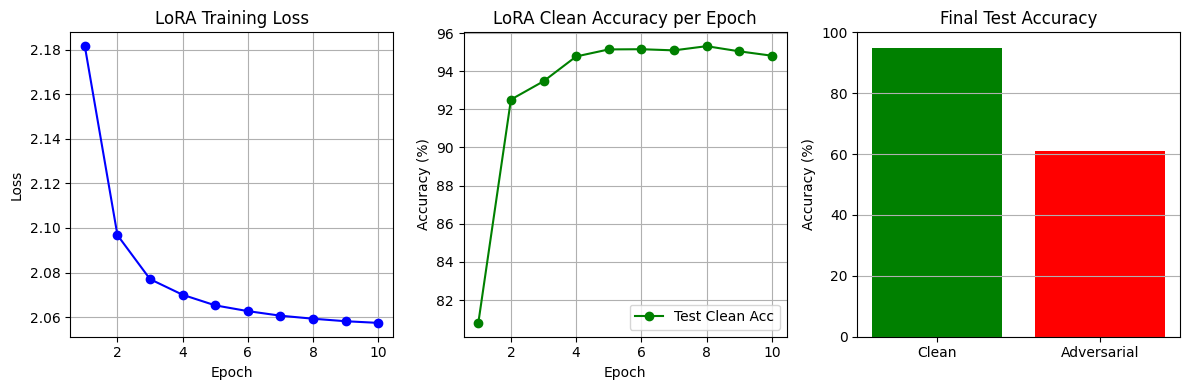


Section 4 Complete: LoRA adaptation with clean training completed.
Adversarial evaluation performed only at the end of training.


In [ ]:
# Helper functions to patch CLIPVisionTransformer
def patch_clip_vision_transformers(model):
    """Patch CLIP vision transformers to remove text-related arguments"""
    keywords_to_remove = ['input_ids', 'attention_mask', 'inputs_embeds']
    for submodule in model.modules():
        if submodule.__class__.__name__ == "CLIPVisionTransformer":
            original_forward = submodule.forward
            def patched_forward(*args, **kwargs):
                for key in keywords_to_remove:
                    if key in kwargs:
                        kwargs.pop(key)
                return original_forward(*args, **kwargs)
            submodule.forward = patched_forward
    return model

def patch_forward(model):
    """Patch forward method to remove unnecessary text-related arguments"""
    keywords_to_remove = ['input_ids', 'attention_mask', 'inputs_embeds']
    original_forward = model.forward
    def patched_forward(*args, **kwargs):
        for key in keywords_to_remove:
            if key in kwargs:
                kwargs.pop(key)
        return original_forward(*args, **kwargs)
    model.forward = patched_forward
    return model

def setup_lora_clip(clip_model, r=8, alpha=32):
    """Setup LoRA adaptation for CLIP vision model"""
    # LoRA configuration for the vision model
    lora_config = LoraConfig(
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.1,
        bias="none",
        task_type=TaskType.FEATURE_EXTRACTION
    )
    # Create a deepcopy to avoid modifying the original model
    vision_model = copy.deepcopy(clip_model.vision_model)
    # Apply LoRA to the vision model
    lora_vision_model = get_peft_model(vision_model, lora_config)

    print("LoRA Configuration:")
    print(f"- Rank (r): {r}")
    print(f"- Alpha: {alpha}")
    print(f"- Target modules: {lora_config.target_modules}")
    lora_vision_model.print_trainable_parameters()

    # Explicitly freeze all non-LoRA parameters to be safe
    for name, param in lora_vision_model.named_parameters():
        if "lora_" not in name:
            param.requires_grad = False
        else:
            print(f"Trainable parameter: {name}")

    # Patch the forward methods to remove unnecessary text-related arguments
    patch_forward(lora_vision_model)
    patch_clip_vision_transformers(lora_vision_model)
    return lora_vision_model

def project_text_features(text_features, in_dim=512, out_dim=768, device='cpu'):
    """Project text features from input dimension to output dimension"""
    projection = nn.Linear(in_dim, out_dim).to(device)
    # Set to eval mode as we are not training this projection layer
    projection.eval()
    with torch.no_grad():
        return projection(text_features)

# PGD Attack for Standard LoRA
def pgd_attack_clip_lora(lora_vision_model, text_features, images, labels,
                         eps=8/255, alpha=2/255, steps=7, device='cpu'):
    """Perform PGD attack on LoRA-adapted CLIP model"""
    # Ensure all tensors are on the correct device and detached
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    text_features = text_features.to(device)

    # Start with the original images
    adv_images = images.clone().detach()
    # Add random noise to start
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(steps):
        # The image needs to be a leaf variable with requires_grad=True to get gradients w.r.t. it
        adv_images.requires_grad = True

        # Forward pass through the model to get features
        outputs = lora_vision_model(pixel_values=adv_images)
        image_features = outputs.pooler_output
        image_features = F.normalize(image_features, dim=1)

        # Calculate loss
        similarity = torch.matmul(image_features, text_features.T)
        loss = F.cross_entropy(similarity, labels)

        # Calculate the gradient of the loss w.r.t. the adversarial image
        grad = torch.autograd.grad(loss, adv_images,
                                   retain_graph=False, create_graph=False)[0]

        # Perform the PGD step: move the image in the direction of the gradient sign
        adv_images = adv_images.detach() + alpha * grad.sign()
        # Project the perturbation back into the epsilon-ball
        delta = torch.clamp(adv_images - images, min=-eps, max=eps)
        # Add the clamped perturbation to the original image and clamp to [0, 1] range
        adv_images = torch.clamp(images + delta, min=0, max=1).detach()

    return adv_images

def train_lora_clean(lora_vision_model, train_loader, test_loader, text_features, num_epochs=8, lr=1e-4, device='cpu'):
    """Train LoRA model on clean images - adversarial evaluation only at the end"""
    print("Starting LoRA Training on Clean Images...")
    # The optimizer should only receive parameters that require gradients.
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, lora_vision_model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=2, gamma=0.7)
    scaler = GradScaler() # For mixed-precision training

    # Store metrics for plotting
    history = {'epoch': [], 'loss': [], 'clean_acc_train': [], 'clean_acc_test': []}

    # Ensure text_features are on the correct device and detached from any graph.
    text_features_device = text_features.to(device).detach()

    for epoch in range(num_epochs):
        lora_vision_model.train() # Set the model to training mode
        epoch_loss = 0.0
        correct_train, total_train = 0, 0

        pbar = tqdm(train_loader, desc=f"LoRA Training Epoch {epoch+1}/{num_epochs}")

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            # --- Main Training Step on Clean Images ---
            optimizer.zero_grad()

            with autocast(): # Use mixed precision
                outputs = lora_vision_model(pixel_values=images)
                image_features = outputs.pooler_output
                image_features = F.normalize(image_features, dim=1)

                similarity = torch.matmul(image_features, text_features_device.T)
                loss = F.cross_entropy(similarity, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # --- End of Training Step ---

            epoch_loss += loss.item()

            # Calculate training accuracy for the current batch to display progress
            with torch.no_grad():
                predictions = similarity.argmax(dim=1)
                correct_train += (predictions == labels).sum().item()
                total_train += labels.size(0)

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Train Clean Acc': f'{100. * correct_train / total_train:.2f}%'
            })

        # --- End of Epoch ---
        avg_loss = epoch_loss / len(train_loader)
        train_accuracy = 100. * correct_train / total_train

        # Only evaluate clean accuracy on test set during training (fast evaluation)
        print(f"\n--- End of Epoch {epoch+1} ---")
        clean_test_accuracy = evaluate_lora_model(lora_vision_model, test_loader, text_features, "clean", device=device)

        # Save history for plotting (no adversarial accuracy during training)
        history['epoch'].append(epoch + 1)
        history['loss'].append(avg_loss)
        history['clean_acc_train'].append(train_accuracy)
        history['clean_acc_test'].append(clean_test_accuracy * 100)

        scheduler.step()
        print(f"Epoch {epoch+1} Summary: Avg Loss={avg_loss:.4f}, Train Clean Acc={train_accuracy:.2f}%, Test Clean Acc={clean_test_accuracy*100:.2f}%")

    return lora_vision_model, history

def evaluate_lora_model(lora_vision_model, test_loader, text_features, attack_type="clean", max_batches=None, device='cpu'):
    """
    Evaluation function handles both clean and adversarial modes.
    For adversarial evaluation, we use adversarial examples generated from ResNet model.
    """
    lora_vision_model.eval() # Set model to evaluation mode
    correct, total = 0, 0
    text_features = text_features.to(device).detach()

    # Load ResNet model for generating adversarial examples
    target_model = torch.hub.load('chenyaofo/pytorch-cifar-models', 'cifar10_resnet20', pretrained=True).to(device)
    target_model.eval()

    batches = test_loader
    if max_batches is not None:
        batches = list(islice(test_loader, max_batches))

    for images, labels in tqdm(batches, desc=f"Evaluating LoRA CLIP ({attack_type})", leave=False):
        images, labels = images.to(device), labels.to(device)
        test_images = images

        if attack_type == "adversarial":
            # Generate adversarial examples using ResNet model regardless of which model we're evaluating
            with torch.enable_grad():
                # Create adversarial examples using PGD attack on ResNet model
                adv_images = images.clone().detach()
                adv_images = adv_images + torch.empty_like(adv_images).uniform_(-8/255, 8/255)
                adv_images = torch.clamp(adv_images, 0, 1).detach()

                for _ in range(7):  # 7 steps as per the original code
                    adv_images.requires_grad = True
                    outputs = target_model(adv_images)
                    loss = F.cross_entropy(outputs, labels)
                    grad = torch.autograd.grad(loss, adv_images, retain_graph=False, create_graph=False)[0]
                    adv_images = adv_images.detach() + (2/255) * grad.sign()
                    delta = torch.clamp(adv_images - images, min=-8/255, max=8/255)
                    adv_images = torch.clamp(images + delta, min=0, max=1).detach()

                # Use these ResNet-based adversarial examples for evaluation
                test_images = adv_images

        # No gradients are needed for the evaluation forward pass
        with torch.no_grad():
            outputs = lora_vision_model(pixel_values=test_images)
            image_features = outputs.pooler_output
            image_features = F.normalize(image_features, dim=1)
            similarity = torch.matmul(image_features, text_features.T)
            predictions = similarity.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"LoRA CLIP {attack_type.capitalize()} Accuracy: {accuracy:.4f} ({correct}/{total})")
    return accuracy

print("\n" + "=" * 60)
print("Section 4: LoRA Implementation and Clean Training")
print("=" * 60)

# Initialize LoRA model
lora_vision_model = setup_lora_clip(clip_model, r=8, alpha=32).to(device)

# Use the text_features that were already created in previous sections
print("Projecting text features from 512 to 768 dimensions for LoRA model...")
lora_text_features = project_text_features(text_features, in_dim=512, out_dim=768, device=device)
lora_text_features = F.normalize(lora_text_features, dim=1).detach()
print("Projected text_features for LoRA shape:", lora_text_features.shape)

# Train the model using the 768-dim features
trained_lora_model, lora_training_history = train_lora_clean(
    lora_vision_model=lora_vision_model,
    train_loader=train_loader,
    test_loader=test_loader,
    text_features=lora_text_features, # Pass the 768-dim features
    num_epochs=10,
    lr=1e-4,
    device=device
)

# Final evaluation - NOW we do adversarial evaluation at the end
print("\n" + "=" * 50)
print("FINAL EVALUATION ON TEST SET")
print("=" * 50)
print("Performing comprehensive evaluation after training completion...")

lora_clean_acc = evaluate_lora_model(trained_lora_model, test_loader, lora_text_features, "clean", device=device)
print("Now performing adversarial evaluation (this may take longer)...")
lora_adv_acc = evaluate_lora_model(trained_lora_model, test_loader, lora_text_features, "adversarial", device=device)

print(f"\nLoRA Results Summary:")
print(f"Final Test Clean Accuracy: {lora_clean_acc:.4f}")
print(f"Final Test Adversarial Accuracy: {lora_adv_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(lora_training_history['epoch'], lora_training_history['loss'], 'b-o')
plt.title('LoRA Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
# Only plotting clean accuracies during training
plt.plot(lora_training_history['epoch'], lora_training_history['clean_acc_test'], 'g-o', label='Test Clean Acc')
plt.title('LoRA Clean Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.bar(['Clean', 'Adversarial'], [lora_clean_acc*100, lora_adv_acc*100], color=['green', 'red'])
plt.title('Final Test Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print("\nSection 4 Complete: LoRA adaptation with clean training completed.")
print("Adversarial evaluation performed only at the end of training.")

## Section 5: Implement TeCoA Training

Section 5: TeCoA (Text-guided Contrastive Adversarial Training)
LoRA Configuration:
- Rank (r): 8
- Alpha: 32
- Target modules: {'v_proj', 'q_proj'}
trainable params: 294,912 || all params: 87,750,912 || trainable%: 0.3361
Trainable parameter: base_model.model.encoder.layers.0.self_attn.v_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.0.self_attn.v_proj.lora_B.default.weight
Trainable parameter: base_model.model.encoder.layers.0.self_attn.q_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.0.self_attn.q_proj.lora_B.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.v_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.v_proj.lora_B.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.q_proj.lora_A.default.weight
Trainable parameter: base_model.model.encoder.layers.1.self_attn.q_proj.lora_B.default.weight
Trainable parameter: base

TeCoA Epoch 1/10:   0%|          | 0/313 [00:00<?, ?it/s]

TeCoA Epoch 1: Loss = 0.5045, Accuracy = 89.41%


TeCoA Epoch 2/10:   0%|          | 0/313 [00:00<?, ?it/s]

TeCoA Epoch 2: Loss = 0.1294, Accuracy = 97.65%


...

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Evaluating TeCoA LoRA (clean):   0%|          | 0/313 [00:00<?, ?it/s]

TeCoA LoRA Clean Accuracy: 0.9620 (9620/10000)


Evaluating TeCoA LoRA (adversarial):   0%|          | 0/313 [00:00<?, ?it/s]

TeCoA LoRA Adversarial Accuracy: 0.6650 (6650/10000)

TeCoA Training Results:
Clean Accuracy: 0.9620
Adversarial Accuracy (ResNet-based attacks): 0.6650


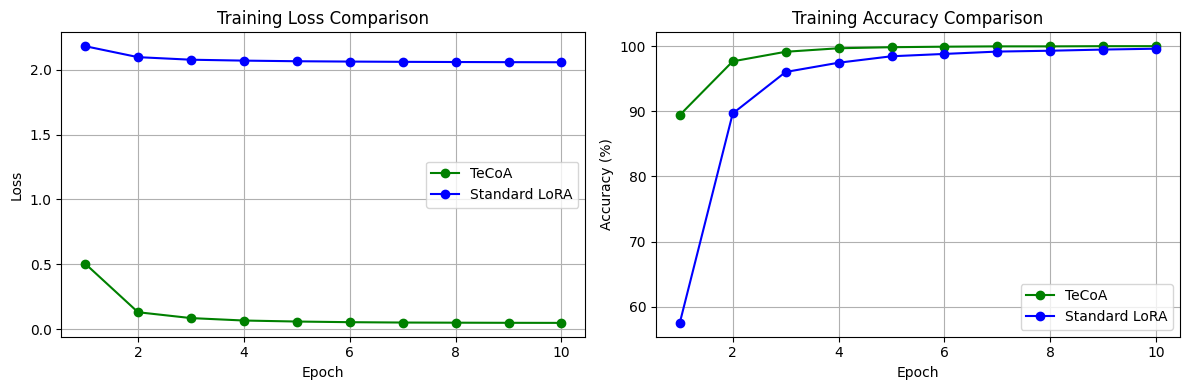


Section 5 Complete: TeCoA implementation and training completed


In [ ]:
def tecoa_contrastive_loss(image_features, text_features, labels, temperature=0.07):
    """
    Text-guided Contrastive Adversarial loss as described in the paper.
    This aligns adversarial image features with text features using contrastive learning.
    """
    # Normalize features
    image_features = F.normalize(image_features, dim=1)
    text_features = F.normalize(text_features, dim=1)

    # Ensure text_features has shape [num_classes, feature_dim]
    # If text_features has shape [feature_dim, num_classes], transpose it
    if text_features.shape[0] == image_features.shape[1]:
        # Text features already in correct shape [feature_dim, num_classes]
        text_features = text_features.T  # Transpose to [num_classes, feature_dim]

    # Check if feature dimensions match after potential transpose
    if text_features.shape[1] != image_features.shape[1]:
        raise ValueError(f"Feature dimensions don't match: image_features={image_features.shape}, text_features={text_features.shape}")

    # Calculate similarity matrix
    logits = torch.matmul(image_features, text_features.T) / temperature  # [batch_size, num_classes]

    # Create one-hot labels
    batch_size = image_features.size(0)
    num_classes = text_features.size(0)
    yij = torch.zeros(batch_size, num_classes, device=image_features.device)
    yij.scatter_(1, labels.view(-1, 1), 1)

    # Calculate contrastive loss
    log_probs = F.log_softmax(logits, dim=1)
    loss = -(yij * log_probs).sum(dim=1).mean()

    return loss

def pgd_attack_tecoa(lora_vision_model, projection_layer, images, labels, text_features,
                     eps=8/255, alpha=2/255, steps=7, temperature=0.07):
    """
    PGD attack for TeCoA (Text-guided Contrastive Adversarial) evaluation.
    """
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    adv_images = images.clone().detach()

    # Add random noise within epsilon ball
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(steps):
        adv_images.requires_grad_()

        outputs = lora_vision_model(pixel_values=adv_images)
        image_features = outputs.pooler_output

        # Project image features to match text feature dimension
        projected_image_features = projection_layer(image_features)

        # Use the contrastive loss function for attack
        loss = tecoa_contrastive_loss(projected_image_features, text_features, labels, temperature)

        grad = torch.autograd.grad(loss, adv_images, retain_graph=False, create_graph=False)[0]
        adv_images = adv_images.detach() + alpha * grad.sign()
        delta = torch.clamp(adv_images - images, min=-eps, max=eps)
        adv_images = torch.clamp(images + delta, 0, 1).detach()

    return adv_images

# Training and Evaluation for TeCoA
def tecoa_training_lora(lora_vision_model, train_loader, text_features,
                        epochs=10, lr=1e-4, temperature=0.07):
    """
    Training with TeCoA (Text-guided Contrastive Adversarial) loss.
    This implementation trains only on clean data, not adversarial examples.
    """
    print("Starting TeCoA Training with LoRA (clean data only)...")

    # Verify that only LoRA parameters are trainable
    trainable_params = []
    for name, param in lora_vision_model.named_parameters():
        if param.requires_grad:
            trainable_params.append(name)
    print(f"Trainable parameters: {len(trainable_params)}")
    print(f"Example trainable parameters: {trainable_params[:5]}")

    # Create a projection layer if image and text feature dimensions don't match
    image_dim = 768  # CLIP vision encoder output dimension
    text_dim = 512   # CLIP text encoder output dimension

    projection = nn.Linear(image_dim, text_dim, bias=False).to(device)
    nn.init.orthogonal_(projection.weight)

    lora_vision_model.train()
    optimizer = optim.AdamW([p for p in lora_vision_model.parameters() if p.requires_grad] +
                           list(projection.parameters()),
                           lr=lr, weight_decay=0.01)
    scheduler = StepLR(optimizer, step_size=2, gamma=0.7)
    scaler = GradScaler()
    training_history = {'epoch': [], 'loss': [], 'accuracy': []}

    for epoch in range(epochs):
        epoch_loss = 0.0
        correct, total = 0, 0
        progress_bar = tqdm(train_loader, desc=f"TeCoA Epoch {epoch+1}/{epochs}")

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Train on clean images using contrastive loss
            with autocast():
                outputs = lora_vision_model(pixel_values=images)
                image_features = outputs.pooler_output
                projected_image_features = projection(image_features)

                # Contrastive loss on clean examples
                loss = tecoa_contrastive_loss(projected_image_features, text_features, labels, temperature)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()

            # Calculate accuracy on clean images for monitoring
            with torch.no_grad():
                clean_features = image_features  # Already computed above
                projected_clean_features = F.normalize(projection(clean_features), dim=1)
                text_features_norm = F.normalize(text_features, dim=1)
                if text_features_norm.shape[0] != 10:
                    text_features_norm = text_features_norm.T
                similarity = projected_clean_features @ text_features_norm.T
                _, predicted = similarity.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}', 'Clean Acc': f'{100.*correct/total:.2f}%'})

        avg_loss = epoch_loss / len(train_loader)
        accuracy = 100. * correct / total
        training_history['epoch'].append(epoch + 1)
        training_history['loss'].append(avg_loss)
        training_history['accuracy'].append(accuracy)
        scheduler.step()

        print(f"TeCoA Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")

    return lora_vision_model, projection, training_history

def evaluate_lora_tecoa_model(lora_vision_model, projection_layer, test_loader, text_features,
                              attack_type="clean", temperature=0.07, resnet_model=None):
    """
    Evaluate TeCoA LoRA model on either clean or adversarial examples.
    When using adversarial mode, it uses adversarial examples generated from ResNet model.
    """
    lora_vision_model.eval()
    projection_layer.eval()  # Set projection layer to evaluation mode
    correct, total = 0, 0

    for images, labels in tqdm(test_loader, desc=f"Evaluating TeCoA LoRA ({attack_type})"):
        images, labels = images.to(device), labels.to(device)
        test_images = images

        if attack_type == "adversarial" and resnet_model is not None:
            # Generate adversarial examples using ResNet model
            # Create PGD attack for ResNet model
            pgd_attack = torchattacks.PGD(resnet_model, eps=8/255, alpha=2/255, steps=7)
            # Generate adversarial examples using ResNet
            test_images = pgd_attack(images, labels)

        # Evaluate CLIP model with the examples (clean or adversarial)
        with torch.no_grad():
            outputs = lora_vision_model(pixel_values=test_images)
            image_features = outputs.pooler_output

            # Project image features to match text feature dimension
            projected_image_features = projection_layer(image_features)
            projected_image_features = F.normalize(projected_image_features, dim=1)

            # Ensure proper text features shape
            norm_text_features = F.normalize(text_features, dim=1)
            if norm_text_features.shape[0] != 10:
                if norm_text_features.shape[1] == 10:
                    norm_text_features = norm_text_features.T
                else:
                    norm_text_features = norm_text_features[:10]

            similarity = torch.matmul(projected_image_features, norm_text_features.T)
            predictions = similarity.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"TeCoA LoRA {attack_type.capitalize()} Accuracy: {accuracy:.4f} ({correct}/{total})")
    return accuracy

# Main section for TeCoA training and evaluation
print("=" * 60)
print("Section 5: TeCoA (Text-guided Contrastive Adversarial Training)")
print("=" * 60)

# Setup LoRA model with frozen base parameters for TeCoA
lora_tecoa_model = setup_lora_clip(clip_model, r=8, alpha=32).to(device)

# Double-check that base parameters are frozen
base_params_trainable = False
for name, param in lora_tecoa_model.named_parameters():
    if "lora_" not in name and param.requires_grad:
        base_params_trainable = True
        print(f"Warning: Non-LoRA parameter {name} is still trainable!")
if not base_params_trainable:
    print("✓ All base parameters are correctly frozen for TeCoA")

# Train with TeCoA on clean data only
tecoa_model_trained, projection_layer, tecoa_training_history = tecoa_training_lora(
    lora_vision_model=lora_tecoa_model,
    train_loader=train_loader,
    text_features=text_features,
    epochs=10,
    lr=1e-4,
    temperature=0.07
)

# Load ResNet model for adversarial example generation during evaluation
resnet_model = torch.hub.load('chenyaofo/pytorch-cifar-models', 'cifar10_resnet20', pretrained=True)
resnet_model = resnet_model.to(device)
resnet_model.eval()

# Evaluate on both clean and adversarial examples at the end of training
print("\nFinal evaluation:")
tecoa_clean_acc = evaluate_lora_tecoa_model(tecoa_model_trained, projection_layer, test_loader, text_features, "clean")
tecoa_adv_acc = evaluate_lora_tecoa_model(tecoa_model_trained, projection_layer, test_loader, text_features, "adversarial", resnet_model=resnet_model)

print(f"\nTeCoA Training Results:")
print(f"Clean Accuracy: {tecoa_clean_acc:.4f}")
print(f"Adversarial Accuracy (ResNet-based attacks): {tecoa_adv_acc:.4f}")

# Plot comparison with standard LoRA
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(tecoa_training_history['epoch'], tecoa_training_history['loss'], 'g-o', label='TeCoA')
plt.plot(lora_training_history['epoch'], lora_training_history['loss'], 'b-o', label='Standard LoRA')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(tecoa_training_history['epoch'], tecoa_training_history['accuracy'], 'g-o', label='TeCoA')
plt.plot(lora_training_history['epoch'], lora_training_history['clean_acc_train'], 'b-o', label='Standard LoRA')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nSection 5 Complete: TeCoA implementation and training completed")

## Section 6: Comprehensive Comparison of Different Training Methods

Section 6: Comprehensive Method Comparison

Method Comparison Results:
--------------------------------------------------------------------------------
Method                    Clean Acc    Adv Acc      Robustness Gap  Description
--------------------------------------------------------------------------------
CLIP (Vanilla)            0.8783       0.0023       0.8760          Original CLIP without adaptation
LoRA + Standard Adv       0.9481       0.6116       0.3365          LoRA with standard adversarial training
LoRA + TeCoA              0.9620       0.6650       0.2970          LoRA with Text-guided Contrastive Adversarial training
--------------------------------------------------------------------------------


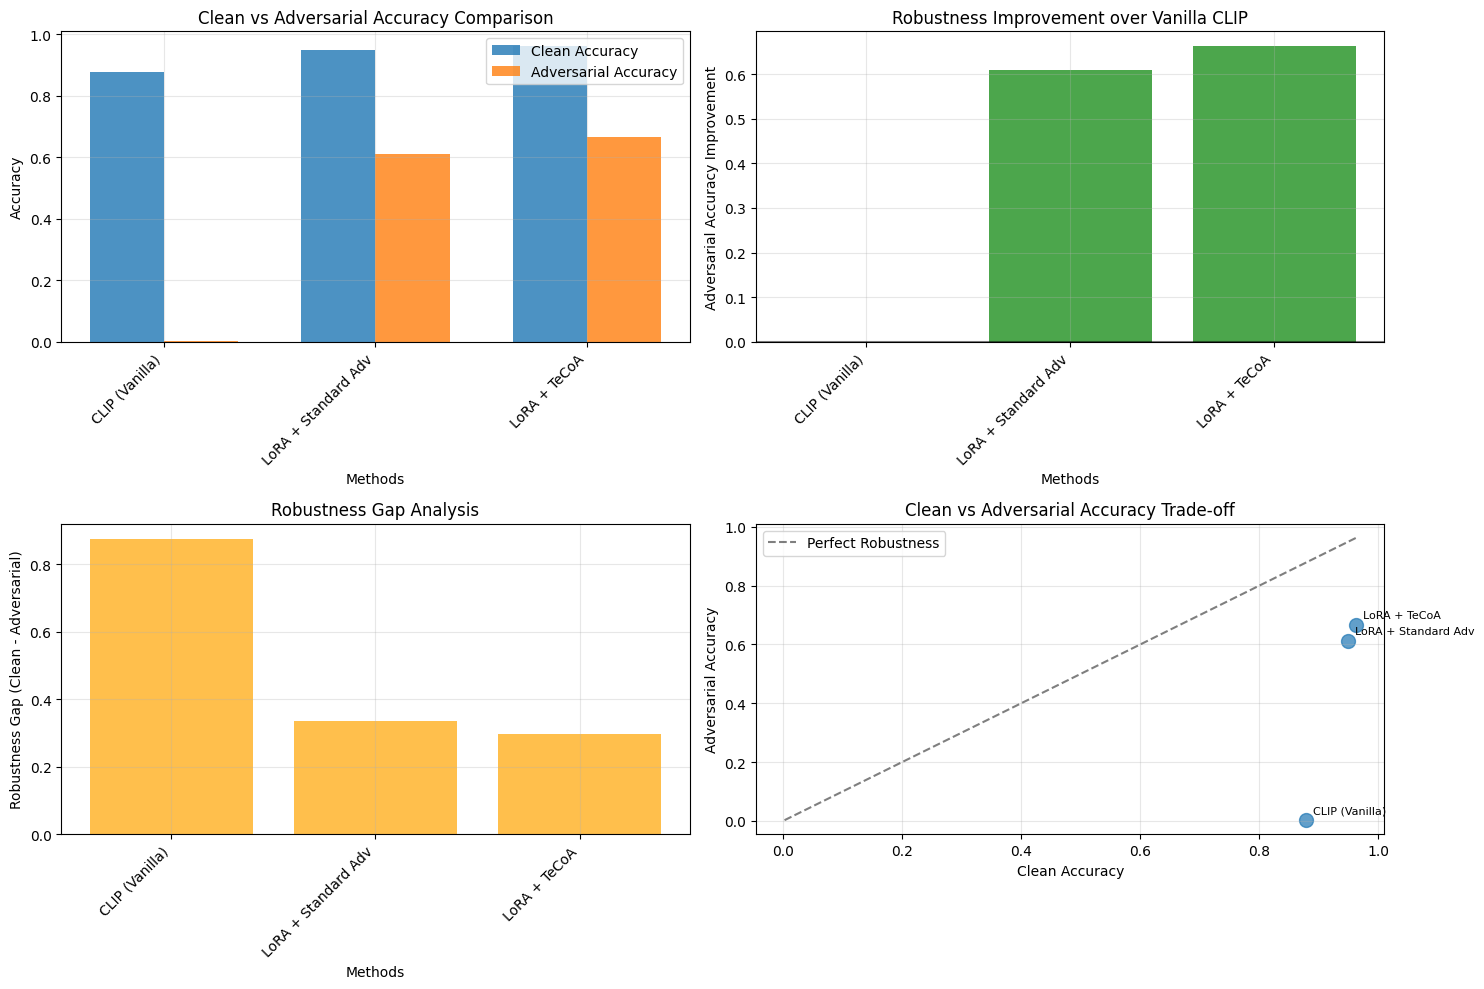


Statistical Analysis:
----------------------------------------
LoRA Standard Adversarial Training Improvement: 0.6093
TeCoA Improvement over Vanilla CLIP: 0.6627
TeCoA Improvement over Standard LoRA: 0.0534

Robustness Efficiency (Adv Acc / Clean Acc):
CLIP (Vanilla): 0.0026
LoRA + Standard Adv: 0.6451
LoRA + TeCoA: 0.6913


In [ ]:
def compare_methods_comprehensive():
    """
    Comprehensive comparison of different training methods
    Following the paper's experimental setup
    """
    print("=" * 60)
    print("Section 6: Comprehensive Method Comparison")
    print("=" * 60)

    # Define all methods to compare based on the paper
    methods = {
        'CLIP (Vanilla)': {
            'clean_acc': clean_accuracy,
            'adv_acc': adversarial_accuracy,
            'description': 'Original CLIP without adaptation'
        },
        'LoRA + Standard Adv': {
            'clean_acc': lora_clean_acc,
            'adv_acc': lora_adv_acc,
            'description': 'LoRA with standard adversarial training'
        },
        'LoRA + TeCoA': {
            'clean_acc': tecoa_clean_acc,
            'adv_acc': tecoa_adv_acc,
            'description': 'LoRA with Text-guided Contrastive Adversarial training'
        }
    }

    # Create comparison table
    print("\nMethod Comparison Results:")
    print("-" * 80)
    print(f"{'Method':<25} {'Clean Acc':<12} {'Adv Acc':<12} {'Robustness Gap':<15} {'Description'}")
    print("-" * 80)

    for method_name, results in methods.items():
        clean_acc = results['clean_acc']
        adv_acc = results['adv_acc']
        gap = clean_acc - adv_acc
        desc = results['description']

        print(f"{method_name:<25} {clean_acc:<12.4f} {adv_acc:<12.4f} {gap:<15.4f} {desc}")

    print("-" * 80)

    # Visualize comparison
    plt.figure(figsize=(15, 10))

    # Subplot 1: Clean vs Adversarial Accuracy
    plt.subplot(2, 2, 1)
    method_names = list(methods.keys())
    clean_accs = [methods[m]['clean_acc'] for m in method_names]
    adv_accs = [methods[m]['adv_acc'] for m in method_names]

    x = np.arange(len(method_names))
    width = 0.35

    plt.bar(x - width/2, clean_accs, width, label='Clean Accuracy', alpha=0.8)
    plt.bar(x + width/2, adv_accs, width, label='Adversarial Accuracy', alpha=0.8)

    plt.xlabel('Methods')
    plt.ylabel('Accuracy')
    plt.title('Clean vs Adversarial Accuracy Comparison')
    plt.xticks(x, method_names, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subplot 2: Robustness Improvement
    plt.subplot(2, 2, 2)
    improvements = [adv_accs[i] - adv_accs[0] for i in range(len(adv_accs))]
    colors = ['red' if imp < 0 else 'green' for imp in improvements]

    plt.bar(method_names, improvements, color=colors, alpha=0.7)
    plt.xlabel('Methods')
    plt.ylabel('Adversarial Accuracy Improvement')
    plt.title('Robustness Improvement over Vanilla CLIP')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Subplot 3: Robustness Gap Analysis
    plt.subplot(2, 2, 3)
    gaps = [clean_accs[i] - adv_accs[i] for i in range(len(clean_accs))]

    plt.bar(method_names, gaps, color='orange', alpha=0.7)
    plt.xlabel('Methods')
    plt.ylabel('Robustness Gap (Clean - Adversarial)')
    plt.title('Robustness Gap Analysis')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)

    # Subplot 4: Trade-off Analysis
    plt.subplot(2, 2, 4)
    plt.scatter(clean_accs, adv_accs, s=100, alpha=0.7)

    for i, method in enumerate(method_names):
        plt.annotate(method, (clean_accs[i], adv_accs[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    plt.xlabel('Clean Accuracy')
    plt.ylabel('Adversarial Accuracy')
    plt.title('Clean vs Adversarial Accuracy Trade-off')
    plt.grid(True, alpha=0.3)

    # Add diagonal line for reference
    min_acc = min(min(clean_accs), min(adv_accs))
    max_acc = max(max(clean_accs), max(adv_accs))
    plt.plot([min_acc, max_acc], [min_acc, max_acc], 'k--', alpha=0.5, label='Perfect Robustness')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Statistical Analysis
    print("\nStatistical Analysis:")
    print("-" * 40)

    # Calculate improvements
    lora_improvement = lora_adv_acc - adversarial_accuracy
    tecoa_improvement = tecoa_adv_acc - adversarial_accuracy
    tecoa_vs_lora = tecoa_adv_acc - lora_adv_acc

    print(f"LoRA Standard Adversarial Training Improvement: {lora_improvement:.4f}")
    print(f"TeCoA Improvement over Vanilla CLIP: {tecoa_improvement:.4f}")
    print(f"TeCoA Improvement over Standard LoRA: {tecoa_vs_lora:.4f}")

    # Robustness efficiency (adversarial accuracy / clean accuracy)
    print(f"\nRobustness Efficiency (Adv Acc / Clean Acc):")
    for method_name, results in methods.items():
        efficiency = results['adv_acc'] / results['clean_acc']
        print(f"{method_name}: {efficiency:.4f}")

    return methods

# Run comprehensive comparison
comparison_results = compare_methods_comprehensive()

## Section 7 (Bonus): Visual Prompting Tuning with TeCoA and Comprehensive Evaluation and Comparison

Text embeddings prepared for all CIFAR-10 classes
VP text features shape: torch.Size([10, 512])
Section 7: Visual Prompting Tuning with TeCoA
Visual Prompting initialized with image prompting
Trainable parameters: 150528
Starting Visual Prompting Training with TeCoA on clean images...


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


VP+TeCoA Epoch 1/10:   0%|          | 0/313 [00:00<?, ?it/s]

VP+TeCoA Epoch 1: Loss = 1.7853, Accuracy = 48.75%


VP+TeCoA Epoch 2/10:   0%|          | 0/313 [00:00<?, ?it/s]

...

VP+TeCoA Epoch 10: Loss = 1.1499, Accuracy = 74.52%


Evaluating VP+TeCoA (clean):   0%|          | 0/313 [00:00<?, ?it/s]

VP+TeCoA Clean Accuracy: 0.5516 (5516/10000)


Evaluating VP+TeCoA (adversarial):   0%|          | 0/313 [00:00<?, ?it/s]

VP+TeCoA Adversarial Accuracy: 0.2643 (2643/10000)

Visual Prompting + TeCoA Results:
Clean Accuracy: 0.5516
Adversarial Accuracy: 0.2643
FINAL COMPREHENSIVE COMPARISON - ALL METHODS
                  Method  Clean Accuracy  Adversarial Accuracy  Robustness Gap Parameters Updated Training Type
           Original CLIP          0.8783                0.0023          0.8760                  0          None
     LoRA + Standard Adv          0.9481                0.6116          0.3365       LoRA weights  Standard Adv
            LoRA + TeCoA          0.9620                0.6650          0.2970       LoRA weights         TeCoA
Visual Prompting + TeCoA          0.5516                0.2643          0.2873     Visual Prompts         TeCoA


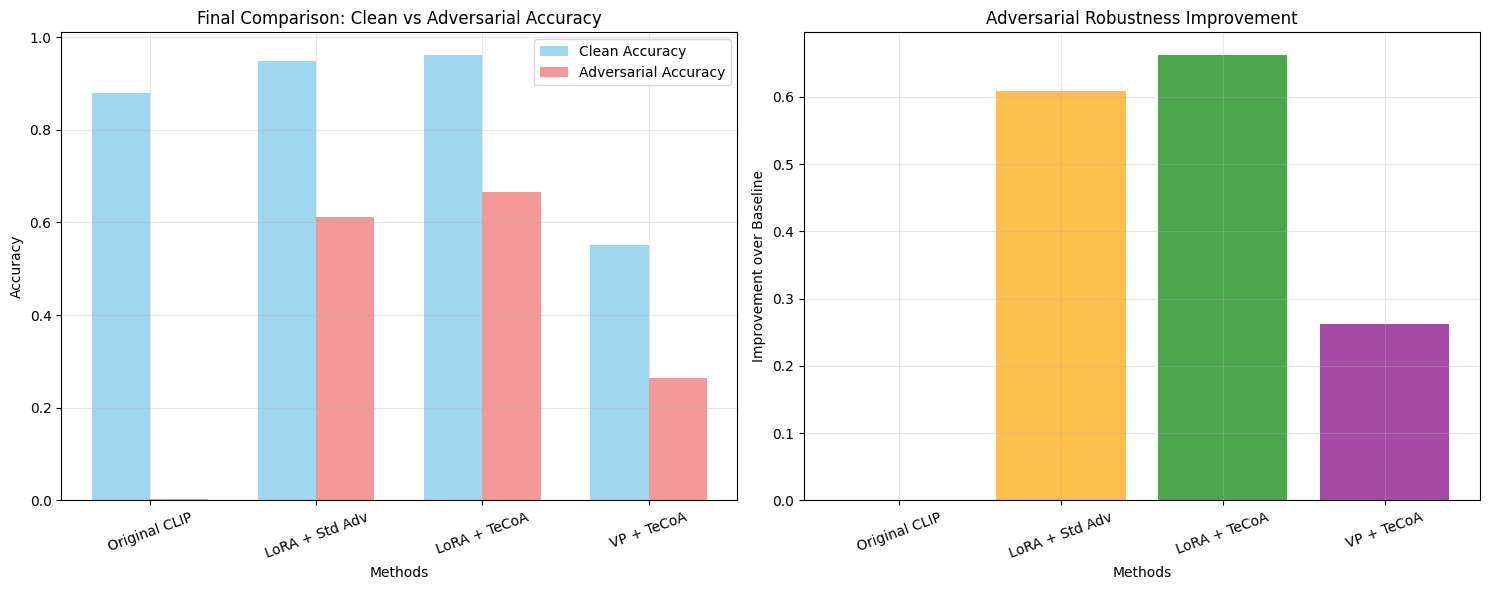


FINAL SUMMARY:
Best Clean Accuracy: 0.9620
Best Adversarial Accuracy: 0.6650
Best Overall Method: LoRA + TeCoA

Section 7 Complete: Visual Prompting with TeCoA implemented and compared


In [6]:
class VisualPromptTuning(nn.Module):
    """
    Visual Prompting Tuning implementation based on the paper.
    Two types: token-level and image-level. Here we implement image-level prompting.
    """
    def __init__(self, clip_model, prompt_size=5, prompt_type="image"):
        super().__init__()
        self.clip_model = clip_model
        self.prompt_type = prompt_type

        if prompt_type == "token":
            # For token-level prompting (this code uses image prompting for simplicity)
            self.prompt_tokens = nn.Parameter(
                torch.randn(prompt_size, clip_model.vision_model.config.hidden_size) * 0.02
            )
            self.prompt_size = prompt_size
        elif prompt_type == "image":
            # Image-level prompting: add learnable noise to the input image
            self.image_prompt = nn.Parameter(torch.randn(3, 224, 224) * 0.02)

        # Freeze all CLIP parameters to ensure they don't get updated during training
        for param in self.clip_model.parameters():
            param.requires_grad = False

        print(f"Visual Prompting initialized with {prompt_type} prompting")
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Trainable parameters: {trainable_params}")

    def forward(self, images):
        if self.prompt_type == "image":
            # Add the image-level prompt to input images
            prompted_images = images + self.image_prompt.unsqueeze(0)
            prompted_images = torch.clamp(prompted_images, 0, 1)
            return self.clip_model.get_image_features(prompted_images)
        elif self.prompt_type == "token":
            # For token prompting, one would modify transformers' inputs
            # For simplicity, we just use the original image
            return self.clip_model.get_image_features(images)

# PGD attack for evaluation only - not used during training
def pgd_attack_visual_prompt(vp_model, images, labels, text_features,
                             eps=8/255, alpha=2/255, steps=7, temperature=0.07):
    """
    PGD attack for Visual Prompting model with TeCoA loss.
    Used only for evaluation, not during training.
    """
    images = images.clone().detach()
    labels = labels.clone().detach()

    # Initialize adversarial images with random noise within epsilon ball
    adv_images = images.clone().detach()
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(steps):
        adv_images = adv_images.clone().detach()
        adv_images.requires_grad_(True)

        # Forward pass through the visual prompting model
        image_features = vp_model(adv_images)  # expected shape (batch, 512)
        image_features = F.normalize(image_features, dim=1)

        # Compute TeCoA contrastive loss
        logits = torch.matmul(image_features, text_features.T) / temperature  # (batch, 10)
        loss = F.cross_entropy(logits, labels)

        # Backward pass
        grad = torch.autograd.grad(loss, adv_images, retain_graph=False, create_graph=False)[0]

        # Update adversarial images
        adv_images = adv_images.detach() + alpha * grad.sign()
        delta = torch.clamp(adv_images - images, min=-eps, max=eps)
        adv_images = torch.clamp(images + delta, 0, 1).detach()

    return adv_images

def train_visual_prompting_tecoa(vp_model, train_loader, text_features, device,
                                 epochs=10, lr=40.0):
    """
    Train the Visual Prompting model with TeCoA loss on CLEAN images.
    The model is only evaluated on adversarial examples, not trained on them.
    """
    print("Starting Visual Prompting Training with TeCoA on clean images...")
    optimizer = optim.SGD(vp_model.parameters(), lr=lr, momentum=0.9)
    scheduler = StepLR(optimizer, step_size=2, gamma=0.7)
    vp_model.train()

    training_history = {'epoch': [], 'loss': [], 'accuracy': []}

    for epoch in range(epochs):
        epoch_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader, desc=f"VP+TeCoA Epoch {epoch+1}/{epochs}")

        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass with CLEAN images (not adversarial)
            image_features = vp_model(images)
            image_features = F.normalize(image_features, dim=1)

            # Calculate TeCoA loss using text features and clean image features
            logits = torch.matmul(image_features, text_features.T) / 0.07
            loss = F.cross_entropy(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            with torch.no_grad():
                predictions = logits.argmax(dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2f}'
            })

        avg_loss = epoch_loss / len(train_loader)
        accuracy = 100. * correct / total
        training_history['epoch'].append(epoch + 1)
        training_history['loss'].append(avg_loss)
        training_history['accuracy'].append(accuracy)
        scheduler.step()

        print(f"VP+TeCoA Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")

    return vp_model, training_history

def evaluate_visual_prompting(vp_model, test_loader, text_features, device, attack_type="clean", resnet_model=None):
    """
    Evaluate the Visual Prompting model on either clean or adversarial images.
    When using adversarial examples, it will use ResNet-generated adversaries.

    Args:
        vp_model: The visual prompting model to evaluate
        test_loader: DataLoader with test images
        text_features: Text embeddings for classification
        device: Device to run evaluation on
        attack_type: "clean" or "adversarial"
        resnet_model: ResNet model to generate adversarial examples (required if attack_type="adversarial")
    """
    vp_model.eval()
    correct = 0
    total = 0

    for images, labels in tqdm(test_loader, desc=f"Evaluating VP+TeCoA ({attack_type})"):
        images = images.to(device)
        labels = labels.to(device)

        if attack_type == "adversarial":
            # Make sure we have a ResNet model for generating adversarial examples
            if resnet_model is None:
                raise ValueError("ResNet model is required for adversarial evaluation")

            # Use ResNet-generated adversarial examples
            with torch.enable_grad():
                # Generate adversarial examples using ResNet model
                adv_images = pgd_attack(resnet_model, images, labels,
                                      eps=8/255, alpha=2/255, steps=7)
            test_images = adv_images
        else:
            test_images = images

        with torch.no_grad():
            image_features = vp_model(test_images)
            image_features = F.normalize(image_features, dim=1)
            similarity = torch.matmul(image_features, text_features.T)
            predictions = similarity.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"VP+TeCoA {attack_type.capitalize()} Accuracy: {accuracy:.4f} ({correct}/{total})")
    return accuracy

def create_final_comparison():
    """
    Create final comprehensive comparison including Visual Prompting.
    """
    methods = ['Original CLIP', 'LoRA + Standard Adv', 'LoRA + TeCoA', 'Visual Prompting + TeCoA']
    # The following variables should be defined in previous sections:
    # clean_accuracy, adversarial_accuracy, lora_clean_acc, lora_adv_acc, tecoa_clean_acc, tecoa_adv_acc,
    # vp_clean_acc, vp_adv_acc.
    clean_accuracies = [clean_accuracy, lora_clean_acc, tecoa_clean_acc, vp_clean_acc]
    adv_accuracies = [adversarial_accuracy, lora_adv_acc, tecoa_adv_acc, vp_adv_acc]

    comparison_data = {
        'Method': methods,
        'Clean Accuracy': clean_accuracies,
        'Adversarial Accuracy': adv_accuracies,
        'Robustness Gap': [c - a for c, a in zip(clean_accuracies, adv_accuracies)],
        'Parameters Updated': ['0', 'LoRA weights', 'LoRA weights', 'Visual Prompts'],
        'Training Type': ['None', 'Standard Adv', 'TeCoA', 'TeCoA']
    }

    final_df = pd.DataFrame(comparison_data)

    print("=" * 90)
    print("FINAL COMPREHENSIVE COMPARISON - ALL METHODS")
    print("=" * 90)
    print(final_df.to_string(index=False, float_format='%.4f'))
    print("=" * 90)

    return final_df

def visualize_final_results():
    """
    Create final visualization with all methods.
    """
    methods = ['Original CLIP', 'LoRA + Std Adv', 'LoRA + TeCoA', 'VP + TeCoA']
    clean_accs = [clean_accuracy, lora_clean_acc, tecoa_clean_acc, vp_clean_acc]
    adv_accs = [adversarial_accuracy, lora_adv_acc, tecoa_adv_acc, vp_adv_acc]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    x = np.arange(len(methods))
    width = 0.35

    ax1.bar(x - width/2, clean_accs, width, label='Clean Accuracy', alpha=0.8, color='skyblue')
    ax1.bar(x + width/2, adv_accs, width, label='Adversarial Accuracy', alpha=0.8, color='lightcoral')
    ax1.set_xlabel('Methods')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Final Comparison: Clean vs Adversarial Accuracy')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods, rotation=20)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    baseline_adv = adversarial_accuracy
    improvements = [0, lora_adv_acc - baseline_adv, tecoa_adv_acc - baseline_adv, vp_adv_acc - baseline_adv]
    colors = ['gray', 'orange', 'green', 'purple']
    ax2.bar(methods, improvements, color=colors, alpha=0.7)
    ax2.set_xlabel('Methods')
    ax2.set_ylabel('Improvement over Baseline')
    ax2.set_title('Adversarial Robustness Improvement')
    ax2.tick_params(axis='x', rotation=20)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

vp_text_features = prepare_text_embeddings(clip_model, tokenizer)  # Should have shape (10, 512)
print("VP text features shape:", vp_text_features.shape)

print("=" * 60)
print("Section 7: Visual Prompting Tuning with TeCoA")
print("=" * 60)

# Initialize Visual Prompting model (using image-level prompting)
vp_model = VisualPromptTuning(clip_model, prompt_size=5, prompt_type="image")
vp_model = vp_model.to(device)

# IMPORTANT: When training the Visual Prompting model, pass the VP-specific text features (vp_text_features)
vp_trained_model, vp_training_history = train_visual_prompting_tecoa(
    vp_model, train_loader, vp_text_features, device, epochs=10, lr=40.0
)

# Evaluate Visual Prompting model using the VP-specific text features.
vp_clean_acc = evaluate_visual_prompting(vp_trained_model, test_loader, vp_text_features, device, "clean")
vp_adv_acc = evaluate_visual_prompting(vp_trained_model, test_loader, vp_text_features, device, "adversarial", resnet_model=target_model)

print(f"\nVisual Prompting + TeCoA Results:")
print(f"Clean Accuracy: {vp_clean_acc:.4f}")
print(f"Adversarial Accuracy: {vp_adv_acc:.4f}")

# Create final comprehensive comparison (assumes variables clean_accuracy, adversarial_accuracy,
# lora_clean_acc, lora_adv_acc, tecoa_clean_acc, tecoa_adv_acc are defined in previous sections)
final_comparison_df = create_final_comparison()

# Create final visualizations
visualize_final_results()

print(f"\nFINAL SUMMARY:")
print(f"Best Clean Accuracy: {max(clean_accuracy, lora_clean_acc, tecoa_clean_acc, vp_clean_acc):.4f}")
print(f"Best Adversarial Accuracy: {max(adversarial_accuracy, lora_adv_acc, tecoa_adv_acc, vp_adv_acc):.4f}")
best_method = "LoRA + TeCoA" if tecoa_adv_acc == max(lora_adv_acc, tecoa_adv_acc, vp_adv_acc) else "Visual Prompting + TeCoA"
print(f"Best Overall Method: {best_method}")

print("\nSection 7 Complete: Visual Prompting with TeCoA implemented and compared")